DECISION TREE IS A UNSUPERVISED LEARNING (NON-PARAMETRIC)

In [4]:
# --- Decision Tree Classifier for Price Category ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# Load your train.csv file
df = pd.read_csv("train.csv")

# Fill missing values in text
df["catalog_content"] = df["catalog_content"].fillna("").astype(str)

# Create categorical price target (Low / Medium / High)
df["price_class"] = pd.qcut(df["price"], q=3, labels=["Low", "Medium", "High"])

print(df.head())
print("\nTarget distribution:\n", df["price_class"].value_counts())



   sample_id  ... price_class
0      33127  ...         Low
1     198967  ...      Medium
2     261251  ...         Low
3      55858  ...        High
4     292686  ...        High

[5 rows x 5 columns]

Target distribution:
 price_class
Low       25393
High      24952
Medium    24655
Name: count, dtype: int64


In [6]:
# Function to extract numeric features from text
def make_features(s):
    s = s.fillna("").astype(str)
    return pd.DataFrame({
        "text_length": s.str.len(),
        "word_count": s.str.split().map(len),
        "digits": s.str.count(r"\d"),
        "commas": s.str.count(","),
        "periods": s.str.count("\.")
    })

# Create numeric features
X = make_features(df["catalog_content"])
X["sample_id"] = df["sample_id"]

# Target
y = df["price_class"]

print("Feature sample:\n", X.head())


<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/hg/6k2xrn0x1hxd4zlz_g32w19h0000gn/T/ipykernel_32097/184535064.py:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  "periods": s.str.count("\.")


Feature sample:
    text_length  word_count  digits  commas  periods  sample_id
0           91          18       6       1        1      33127
1          511          80      17       4        1     198967
2          328          59      12       2        2     261251
3         1318         211      17      14        9      55858
4          155          28      13       2        5     292686


In [7]:
# Split into train/test sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and train Decision Tree Classifier
model = DecisionTreeClassifier(max_depth=6, criterion="entropy", random_state=42)
model.fit(X_train, y_train)

# Predict on validation set
y_pred = model.predict(X_val)


✅ Accuracy: 45.79%

Classification Report:
               precision    recall  f1-score   support

        High       0.51      0.38      0.44      4990
         Low       0.45      0.76      0.56      5079
      Medium       0.41      0.22      0.29      4931

    accuracy                           0.46     15000
   macro avg       0.46      0.46      0.43     15000
weighted avg       0.46      0.46      0.43     15000



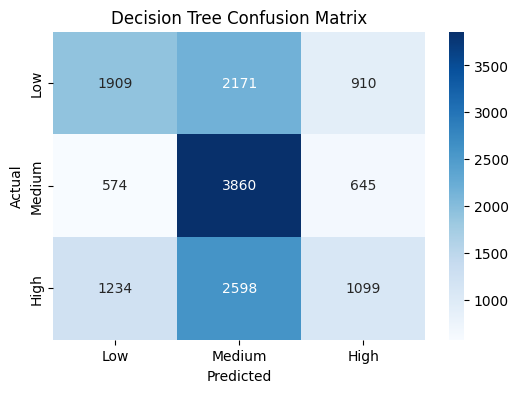

In [8]:
# Evaluation
acc = accuracy_score(y_val, y_pred)
print(f"✅ Accuracy: {acc*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_val, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


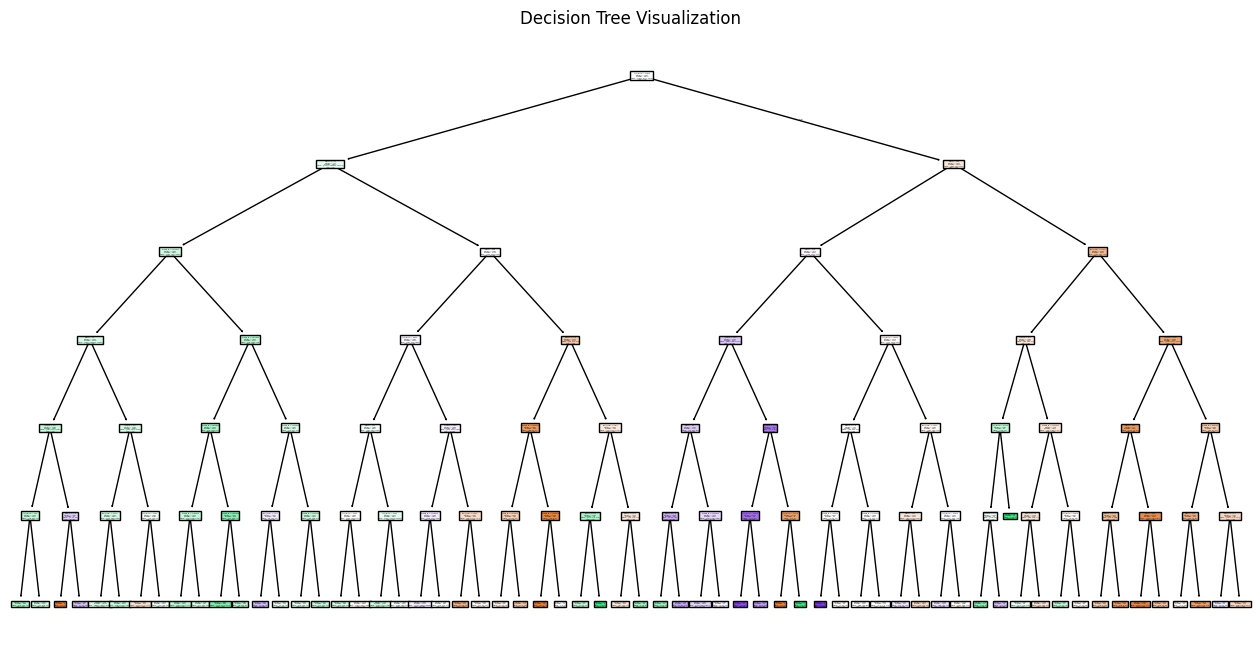

In [9]:
plt.figure(figsize=(16,8))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.title("Decision Tree Visualization")
plt.show()


In [10]:
# Load test.csv and apply the same feature extraction
test_df = pd.read_csv("test.csv")
test_df["catalog_content"] = test_df["catalog_content"].fillna("").astype(str)

X_test = make_features(test_df["catalog_content"])
X_test["sample_id"] = test_df["sample_id"]

# Predict categories
test_df["predicted_price_class"] = model.predict(X_test)

# Save predictions
test_df.to_csv("test_decision_tree_predictions.csv", index=False)
print("💾 Saved predictions to 'test_decision_tree_predictions.csv'")


💾 Saved predictions to 'test_decision_tree_predictions.csv'
